<a href="https://colab.research.google.com/github/salmamahmoud732/breast/blob/main/Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [2]:
df = pd.read_csv("/content/breast-cancer.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [5]:
df.fillna(df.mean(numeric_only=True), inplace=True)

df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [6]:
if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


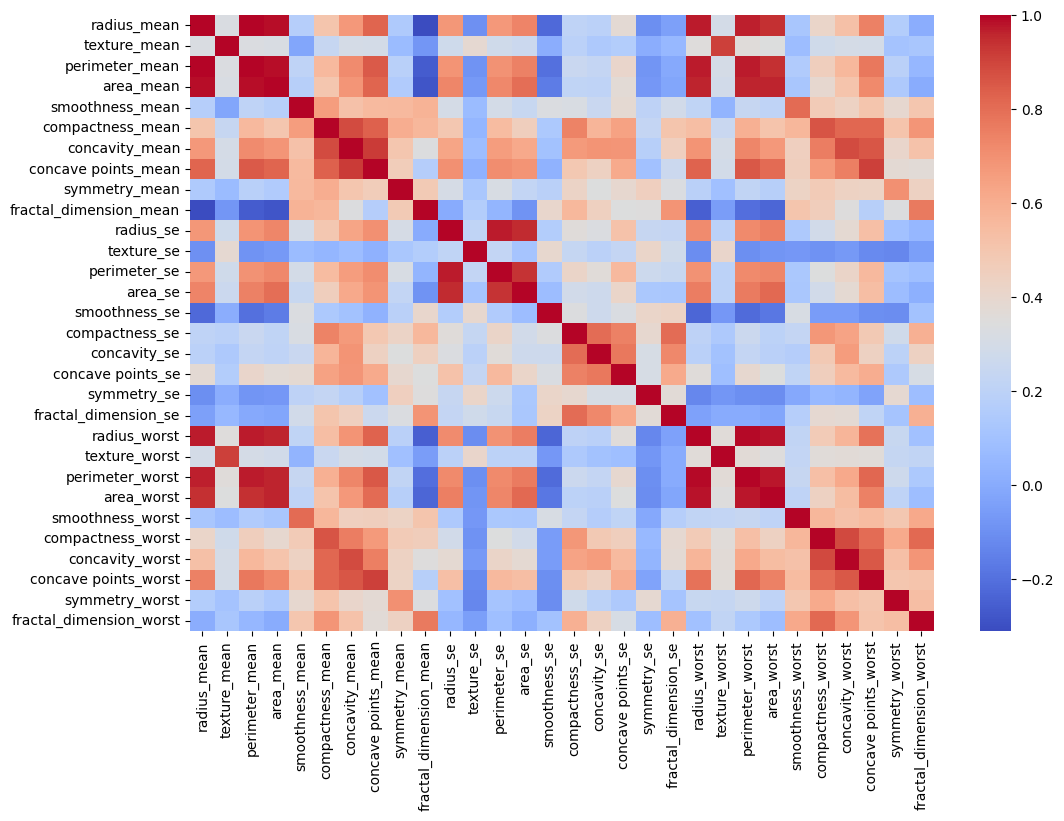

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.show()

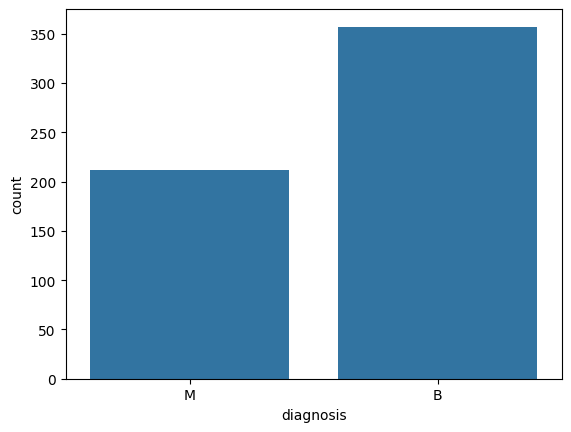

In [9]:
sns.countplot(x="diagnosis", data=df)

plt.show()

In [10]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [11]:
df_encoded = df.copy()
df_encoded['diagnosis'] = df_encoded['diagnosis'].map({'M': 1, 'B': 0})

correlation = df_encoded.corr(numeric_only=True)

target_corr = correlation["diagnosis"].abs()

target_corr

,diagnosis
diagnosis,1.000000
radius_mean,0.730029
texture_mean,0.415185
perimeter_mean,0.742636
area_mean,0.708984
smoothness_mean,0.358560
compactness_mean,0.596534
concavity_mean,0.696360
concave points_mean,0.776614
symmetry_mean,0.330499


In [12]:
threshold = 0.1

low_corr = target_corr[target_corr < threshold].index

print(low_corr)

df.drop(columns=low_corr, inplace=True)

Index(['fractal_dimension_mean', 'texture_se', 'smoothness_se', 'symmetry_se',
       'fractal_dimension_se'],
      dtype='object')


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  radius_se                569 non-null    float64
 11  perimeter_se             569 non-null    float64
 12  area_se                  569 non-null    float64
 13  compactness_se           569 non-null    float64
 14  concavity_se             5

In [14]:
df.shape

(569, 26)

In [15]:
selector = SelectKBest(score_func=f_classif, k=10)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print(selected_features)

Index(['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean',
       'concave points_mean', 'radius_worst', 'perimeter_worst', 'area_worst',
       'concavity_worst', 'concave points_worst'],
      dtype='object')


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [18]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [19]:
knn_pred = knn.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, knn_pred))

print(classification_report(y_test, knn_pred))

Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           B       0.99      0.97      0.98        71
           M       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [20]:
scores = cross_val_score(knn, X_selected, y, cv=5)

print(scores)

print(scores.mean())

[0.86842105 0.93859649 0.93859649 0.94736842 0.92035398]
0.9226672876882471


In [21]:
params = {
    "n_neighbors":[3,5,7,9,11]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=5
)

grid_knn.fit(X_train, y_train)

print(grid_knn.best_params_)

{'n_neighbors': 3}


In [22]:
best_knn = grid_knn.best_estimator_

pred = best_knn.predict(X_test)

print(accuracy_score(y_test,pred))

0.9736842105263158


In [23]:
svm = SVC(probability=True)

svm.fit(X_train,y_train)

SVC(probability=True)

In [24]:
svm_pred = svm.predict(X_test)

print(accuracy_score(y_test,svm_pred))

print(classification_report(y_test,svm_pred))

0.9649122807017544
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        71
           M       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [25]:
scores = cross_val_score(svm, X_selected, y, cv=5)

print(scores)

print(scores.mean())

[0.85964912 0.89473684 0.92982456 0.93859649 0.9380531 ]
0.9121720229777985


In [26]:
param_grid = {

    "C":[0.1,1,10,100],

    "kernel":["linear","rbf"],

    "gamma":["scale","auto"]

}

grid = GridSearchCV(

    SVC(probability=True),

    param_grid,

    cv=5

)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [27]:
best_svm = grid.best_estimator_

prediction = best_svm.predict(X_test)

print(accuracy_score(y_test,prediction))

0.9736842105263158


In [28]:
probabilities = best_svm.predict_proba(X_test)[:,1]

In [29]:
threshold = 0.5

prediction = (probabilities >= threshold).astype(int)

y_test_numeric = y_test.map({best_svm.classes_[0]: 0, best_svm.classes_[1]: 1})

print(accuracy_score(y_test_numeric,prediction))

0.9736842105263158


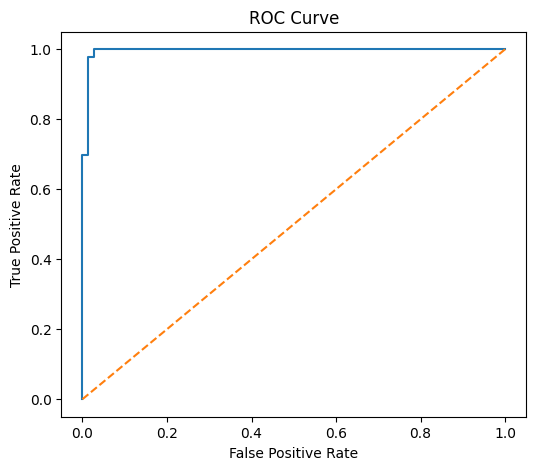

In [30]:
fpr, tpr, _ = roc_curve(y_test_numeric, probabilities)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

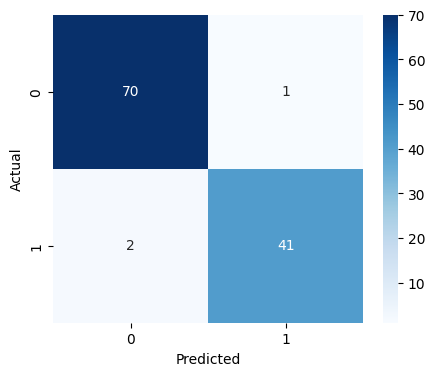

In [31]:
cm = confusion_matrix(y_test_numeric,prediction)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [32]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, log_pred))

print(classification_report(y_test, log_pred))

Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           B       0.99      0.97      0.98        71
           M       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [33]:
from sklearn.model_selection import GridSearchCV

param_log = {
    "C":[0.01,0.1,1,10,100],
    "solver":["liblinear","lbfgs"]
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_log,
    cv=5
)

grid_log.fit(X_train,y_train)

print(grid_log.best_params_)

{'C': 10, 'solver': 'liblinear'}


In [34]:
best_log = grid_log.best_estimator_

pred = best_log.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred))

Accuracy: 0.9824561403508771


In [35]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

print(accuracy_score(y_test,dt_pred))

print(classification_report(y_test,dt_pred))

0.9298245614035088
              precision    recall  f1-score   support

           B       0.93      0.96      0.94        71
           M       0.93      0.88      0.90        43

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [36]:
param_dt = {

    "max_depth":[3,5,7,10,None],

    "min_samples_split":[2,5,10],

    "criterion":["gini","entropy"]

}

grid_dt = GridSearchCV(

    DecisionTreeClassifier(random_state=42),

    param_dt,

    cv=5

)

grid_dt.fit(X_train,y_train)

print(grid_dt.best_params_)

{'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 2}


In [37]:
best_dt = grid_dt.best_estimator_

pred = best_dt.predict(X_test)

print(accuracy_score(y_test,pred))

0.9298245614035088


In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

print(accuracy_score(y_test,rf_pred))

print(classification_report(y_test,rf_pred))

0.956140350877193
              precision    recall  f1-score   support

           B       0.96      0.97      0.97        71
           M       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [39]:
param_rf = {

    "n_estimators":[20,50,100],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5],

    "criterion":["gini","entropy"]

}

grid_rf = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_rf,

    cv=5

)

grid_rf.fit(X_train,y_train)

print(grid_rf.best_params_)

{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


In [40]:
best_rf = grid_rf.best_estimator_

pred = best_rf.predict(X_test)

print(accuracy_score(y_test,pred))

0.9473684210526315


In [41]:
models = {

    "Logistic":best_log,

    "Decision Tree":best_dt,

    "Random Forest":best_rf,

    "KNN":best_knn,

    "SVM":best_svm

}

for name,model in models.items():

    scores = cross_val_score(model,X_selected,y,cv=5)

    print(name)

    print("Scores:",scores)

    print("Average:",scores.mean())

    print("-"*40)

Logistic
Scores: [0.92982456 0.93859649 0.96491228 0.95614035 0.96460177]
Average: 0.9508150908244062
----------------------------------------
Decision Tree
Scores: [0.89473684 0.92105263 0.9122807  0.9122807  0.9380531 ]
Average: 0.9156807949076231
----------------------------------------
Random Forest
Scores: [0.92105263 0.92105263 0.99122807 0.95614035 0.96460177]
Average: 0.9508150908244062
----------------------------------------
KNN
Scores: [0.88596491 0.92105263 0.92982456 0.92982456 0.89380531]
Average: 0.9120943952802358
----------------------------------------
SVM
Scores: [0.87719298 0.92105263 0.9122807  0.94736842 0.9380531 ]
Average: 0.9191895668374475
----------------------------------------


In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results=[]

# Define the mapping for 'B' and 'M' to 0 and 1
# Assuming 'M' is the positive class (1) and 'B' is the negative class (0)
label_mapping = {'B': 0, 'M': 1}

for name,model in models.items():

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    # Map y_test and pred to numeric for roc_auc_score
    y_test_numeric = y_test.map(label_mapping)
    pred_numeric = pd.Series(pred).map(label_mapping)

    results.append({

        "Model":name,

        "Accuracy":accuracy_score(y_test,pred),

        "Precision":precision_score(y_test,pred, pos_label='M'),

        "Recall":recall_score(y_test,pred, pos_label='M'),

        "F1":f1_score(y_test,pred, pos_label='M'),

        "ROC_AUC":roc_auc_score(y_test_numeric,pred_numeric)

    })

comparison=pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic,0.982456,0.976744,0.976744,0.976744,0.981330
1,Decision Tree,0.929825,0.948718,0.860465,0.902439,0.916148
2,Random Forest,0.947368,0.951220,0.906977,0.928571,0.939404
3,KNN,0.973684,0.954545,0.976744,0.965517,0.974288
4,SVM,0.973684,0.976190,0.953488,0.964706,0.969702


In [43]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic,0.982456,0.976744,0.976744,0.976744,0.981330
4,SVM,0.973684,0.976190,0.953488,0.964706,0.969702
3,KNN,0.973684,0.954545,0.976744,0.965517,0.974288
2,Random Forest,0.947368,0.951220,0.906977,0.928571,0.939404
1,Decision Tree,0.929825,0.948718,0.860465,0.902439,0.916148


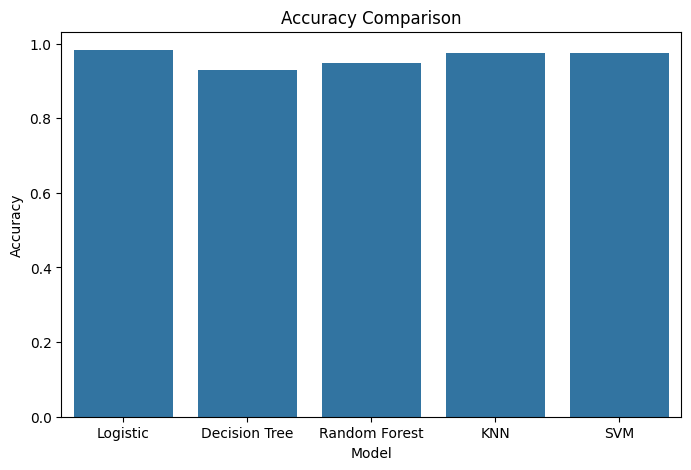

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison")

plt.show()

In [45]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print(best_model)

Model        Logistic
Accuracy     0.982456
Precision    0.976744
Recall       0.976744
F1           0.976744
ROC_AUC       0.98133
Name: 0, dtype: object


In [46]:
df.shape

(569, 26)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  radius_se                569 non-null    float64
 11  perimeter_se             569 non-null    float64
 12  area_se                  569 non-null    float64
 13  compactness_se           569 non-null    float64
 14  concavity_se             5